<a href="https://colab.research.google.com/github/Siya-prog/retail-sales-eda/blob/main/Retail_Sales_Insights_using_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()


Saving retail_sales_dataset.csv to retail_sales_dataset.csv


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("retail_sales_dataset.csv")

# Clean column names
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")

# Preview
df.head()

,Transaction_ID,Date,Customer_ID,Gender,Age,Product_Category,Quantity,Price_per_Unit,Total_Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [12]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction_ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer_ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product_Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price_per_Unit    1000 non-null   int64 
 8   Total_Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [13]:
df.describe()

print("Mean:\n", df.mean(numeric_only=True))
print("\nMedian:\n", df.median(numeric_only=True))
print("\nMode:\n", df.mode().iloc[0])

Mean:
 Transaction_ID    500.500
Age                41.392
Quantity            2.514
Price_per_Unit    179.890
Total_Amount      456.000
dtype: float64

Median:
 Transaction_ID    500.5
Age                42.0
Quantity            3.0
Price_per_Unit     50.0
Total_Amount      135.0
dtype: float64

Mode:
 Transaction_ID               1
Date                2023-05-16
Customer_ID            CUST001
Gender                  Female
Age                       43.0
Product_Category      Clothing
Quantity                   4.0
Price_per_Unit            50.0
Total_Amount              50.0
Name: 0, dtype: object


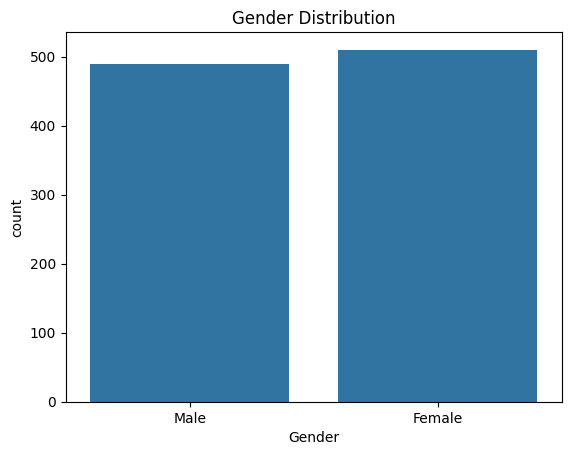

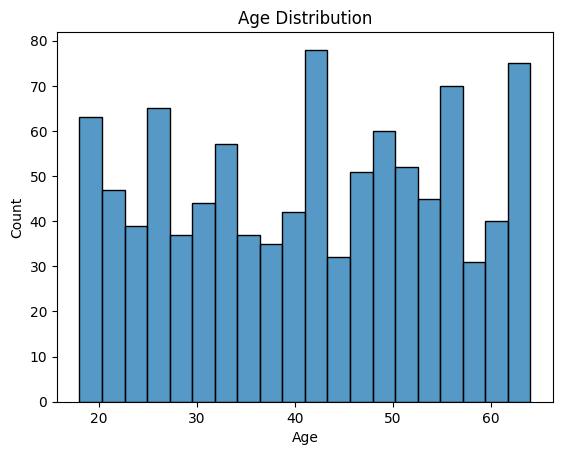

In [14]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

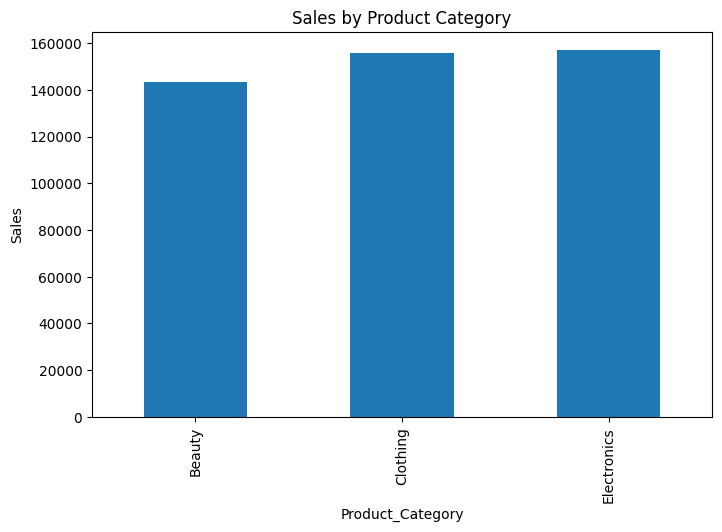

In [15]:
product_sales = df.groupby('Product_Category')['Total_Amount'].sum()

product_sales.plot(kind='bar', figsize=(8,5))
plt.title("Sales by Product Category")
plt.ylabel("Sales")
plt.show()

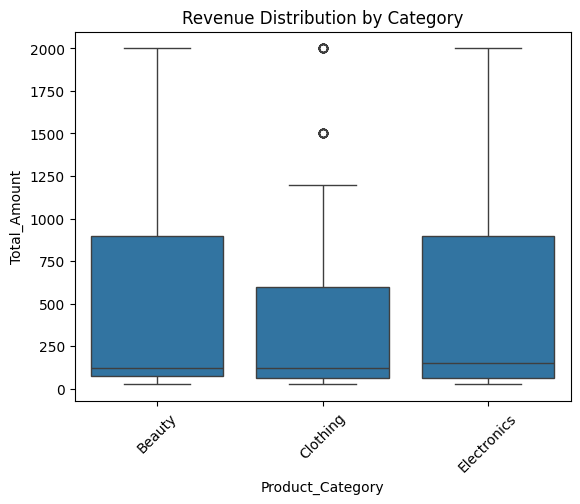

In [16]:
sns.boxplot(x='Product_Category', y='Total_Amount', data=df)
plt.xticks(rotation=45)
plt.title("Revenue Distribution by Category")
plt.show()

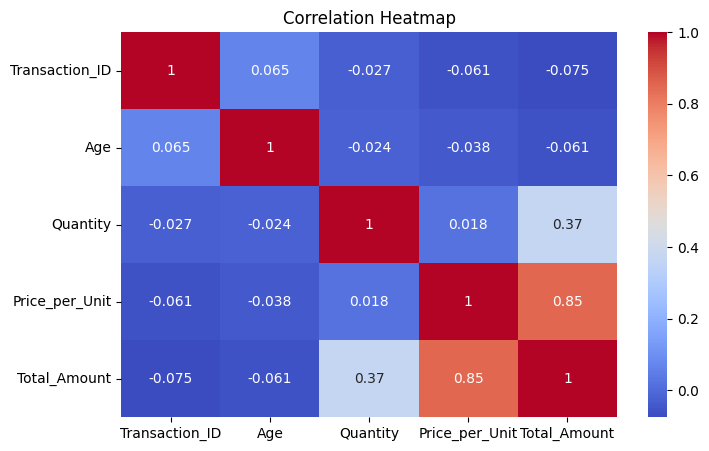

In [17]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()